   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  
0    -122.23  
1    -122.22  
2    -122.24  
3    -122.25  
4    -122.25  
0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: MedHouseVal, dtype: float64
Shape of X: (20640, 8)
Missing values before cleaning:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64
Shape after removing missing values: (20640, 8)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Baseline Train MSE: 0.22777732804872386
Validation MSE: 0.28121556149977345
Test MSE: 0.24817189319759095
numbers of Duplicate coordinates： 4789
       Latitude  Longitude
14759     32.56    -117.06
14760     32.56    -117.06
14753     32.56    -117.05
14754     32.56    -117.05
14758     32.56    -117.05
...         ...        ...
2591      40.88    -124.09
2618      40.93    -124.11
2617      40.93    -124.11
18837     41.73    -122.64
18836     41.73    -122.64

[7749 rows x 2 columns]

=== Repetitive statistics based on latitude and longitude ===
    Repetition frequency of coordinate points  number of coordinate points
0                                           1                         7111
1                                           2                         1836
2                                           3                          690
3                                           4                          269
4                                           5                       

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (64, 32) Validation MSE: 0.28121556149977345


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (128, 64) Validation MSE: 0.2776371479802854


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


Architecture: (128, 64, 32) Validation MSE: 0.2962397595379285

=== Architecture Experiment Results ===
    Architecture  Validation_MSE
0             32        0.313691
1             64        0.313980
2       (64, 32)        0.281216
3      (128, 64)        0.277637
4  (128, 64, 32)        0.296240


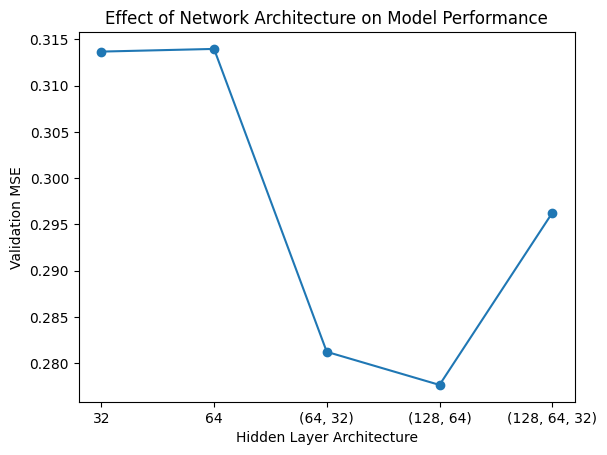

In [2]:

# ============================================================
# Baseline Improvement Experiment 1: Hidden Layer Architecture
# ============================================================

# English:
# This experiment tests different neural network architectures
# to see how the number of layers and neurons affects model performance.

# 中文：
# 这个实验测试不同的神经网络结构
# 观察隐藏层数量和神经元数量对模型预测性能的影响。
%run main.ipynb
import matplotlib.pyplot as plt
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
import pandas as pd


# ------------------------------------------------------------
# Step 1: Define architectures to test
# 步骤1：定义要测试的神经网络结构
# ------------------------------------------------------------

# English:
# Each tuple represents the number of neurons in hidden layers.
# Example: (64,32) means two hidden layers with 64 and 32 neurons.

# 中文：
# 每个元组表示隐藏层结构。
# 例如 (64,32) 表示两个隐藏层，分别有64和32个神经元。

architectures = [
    (32),
    (64),
    (64,32),   # baseline
    (128,64),
    (128,64,32)
]


# 用于保存实验结果
# store experiment results
results = []


# ------------------------------------------------------------
# Step 2: Train models with different architectures
# 步骤2：使用不同结构训练模型
# ------------------------------------------------------------

for arch in architectures:

    # English:
    # Create a neural network model using this architecture

    # 中文：
    # 创建一个使用该结构的神经网络模型

    model_exp = MLPRegressor(
        hidden_layer_sizes=arch,
        activation='tanh',        # keep same as baseline
        solver='adam',
        learning_rate_init=1e-3,
        max_iter=300,
        random_state=26
    )

    # Train model
    # 训练模型
    model_exp.fit(X_train, y_train)

    # Predict validation set
    # 在验证集上进行预测
    val_pred = model_exp.predict(X_val)

    # Calculate MSE
    # 计算均方误差
    val_mse = mean_squared_error(y_val, val_pred)

    # 保存结果
    results.append(val_mse)

    print("Architecture:", arch, "Validation MSE:", val_mse)


# ------------------------------------------------------------
# Step 3: Create results table
# 步骤3：生成结果表格
# ------------------------------------------------------------

results_table = pd.DataFrame({
    "Architecture": architectures,
    "Validation_MSE": results
})

print("\n=== Architecture Experiment Results ===")
print(results_table)


# ------------------------------------------------------------
# Step 4: Plot results
# 步骤4：绘制实验结果图
# ------------------------------------------------------------

plt.figure()

plt.plot(range(len(architectures)), results, marker='o')

plt.xticks(range(len(architectures)), architectures)

plt.xlabel("Hidden Layer Architecture")
plt.ylabel("Validation MSE")

plt.title("Effect of Network Architecture on Model Performance")

plt.show()

/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(



=== Validation MSE Table ===
Activation     identity      relu      tanh
Architecture                               
(128, 64)      0.540073  0.279279  0.277637
(128, 64, 32)  0.534954  0.298666  0.296240
(64, 32)       0.536516  0.289044  0.281216
32             0.526582  0.326200  0.313691
64             0.531246  0.327152  0.313980


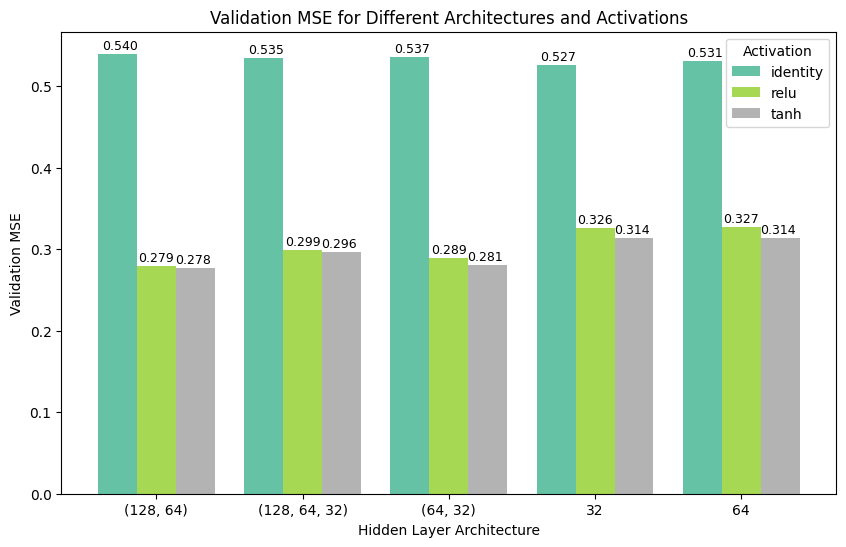

In [4]:
# ------------------------------------------------------------
# Step 0: Define architectures and activations
# ------------------------------------------------------------
architectures = [
    (32),
    (64),
    (64,32),   # baseline
    (128,64),
    (128,64,32)
]

activations = ['tanh', 'relu', 'identity']  # 3 variants

# Store results in a list
results = []

# ------------------------------------------------------------
# Step 1: Train models for all combinations
# ------------------------------------------------------------
for arch in architectures:
    for act in activations:
        model = MLPRegressor(
            hidden_layer_sizes=arch,
            activation=act,
            solver='adam',
            learning_rate_init=1e-3,
            max_iter=300,
            random_state=26
        )
        model.fit(X_train, y_train)
        val_pred = model.predict(X_val)
        val_mse = mean_squared_error(y_val, val_pred)
        results.append({
            'Architecture': str(arch),
            'Activation': act,
            'Validation_MSE': val_mse
        })

# ------------------------------------------------------------
# Step 2: Convert results to DataFrame and pivot for bar chart
# ------------------------------------------------------------
results_df = pd.DataFrame(results)
print("\n=== Validation MSE Table ===")
print(results_df.pivot(index='Architecture', columns='Activation', values='Validation_MSE'))

pivot_table = results_df.pivot(index='Architecture', columns='Activation', values='Validation_MSE')

# ------------------------------------------------------------
# Step 3: Plot grouped bar chart
# ------------------------------------------------------------
pivot_table.plot(kind='bar', figsize=(10,6), width=0.8, colormap='Set2')

plt.ylabel("Validation MSE")
plt.xlabel("Hidden Layer Architecture")
plt.title("Validation MSE for Different Architectures and Activations")
plt.xticks(rotation=0)
plt.legend(title="Activation")
#identity 是隐藏层激活函数的一种，意思是线性激活
# Add value labels on top of each bar
for i, arch in enumerate(pivot_table.index):
    for j, act in enumerate(pivot_table.columns):
        mse = pivot_table.loc[arch, act]
        plt.text(i + j*0.25 - 0.25, mse + 0.002, f"{mse:.3f}", ha='center', va='bottom', fontsize=9)

plt.show()